In [1]:
print("Jai Shree Krishna!")

Jai Shree Krishna!


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Analysis for claims_and_billing dataset

In [3]:
billing = pd.read_csv('claims_and_billing.csv')

In [4]:
billing.head()

,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,06-02-2025 00:00,1971.52,0.00,Denied,Claim Billed to Wrong Payer
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,01-05-2025 00:00,1243.80,736.05,Paid,NaN
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,23-02-2025 00:00,4854.11,2676.12,Paid,NaN
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,20-04-2025 00:00,2638.21,1861.39,Paid,NaN
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaN,1046.99,1046.99,Paid,NaN


In [5]:
billing.shape

(70000, 11)

In [6]:
billing.columns

Index(['billing_id', 'patient_id', 'encounter_id', 'insurance_provider',
       'payment_method', 'claim_id', 'claim_billing_date', 'billed_amount',
       'paid_amount', 'claim_status', 'denial_reason'],
      dtype='object')

In [7]:
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   billing_id          70000 non-null  object 
 1   patient_id          70000 non-null  object 
 2   encounter_id        70000 non-null  object 
 3   insurance_provider  70000 non-null  object 
 4   payment_method      70000 non-null  object 
 5   claim_id            59638 non-null  object 
 6   claim_billing_date  59638 non-null  object 
 7   billed_amount       70000 non-null  float64
 8   paid_amount         70000 non-null  float64
 9   claim_status        70000 non-null  object 
 10  denial_reason       5998 non-null   object 
dtypes: float64(2), object(9)
memory usage: 5.9+ MB


In [8]:
billing.describe()

,billed_amount,paid_amount
count,70000.000000,70000.000000
mean,1612.866283,1040.652151
std,2047.355083,1478.713641
min,100.070000,0.000000
25%,697.047500,366.572500
50%,1214.110000,755.785000
75%,2090.125000,1357.895000
max,38191.350000,38191.350000


In [9]:
missing = billing.isnull().sum()

missing = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values,
    'Missing %': ((missing.values / len(billing)) * 100).round(2)
})

missing.sort_values(
    by='Missing %',
    ascending=False
).head(20)

,Column,Missing Values,Missing %
10,denial_reason,64002,91.43
6,claim_billing_date,10362,14.80
5,claim_id,10362,14.80
2,encounter_id,0,0.00
1,patient_id,0,0.00
0,billing_id,0,0.00
4,payment_method,0,0.00
3,insurance_provider,0,0.00
7,billed_amount,0,0.00
8,paid_amount,0,0.00


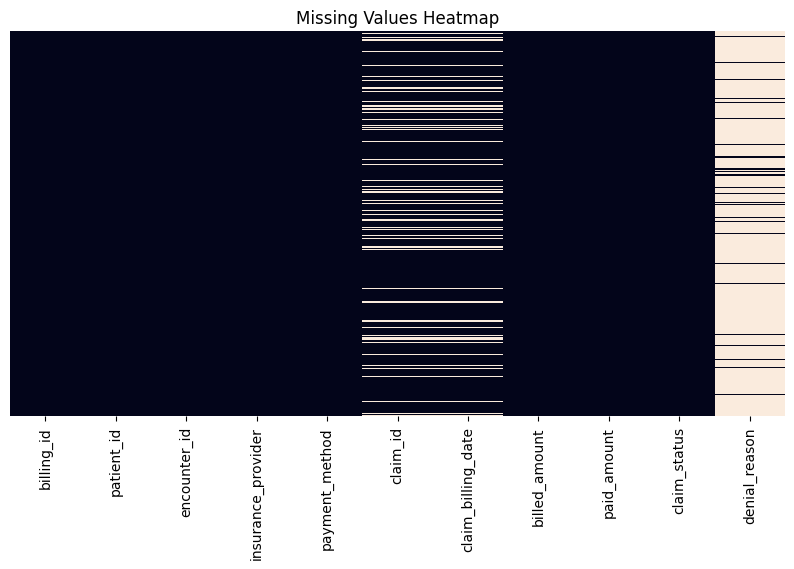

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(
    billing.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')
plt.show()

In [11]:
billing.duplicated().sum()

np.int64(0)

In [12]:
billing.drop_duplicates(inplace=True)

In [13]:
num_cols = billing.select_dtypes(
    include=np.number
).columns

num_cols

Index(['billed_amount', 'paid_amount'], dtype='object')

In [14]:
billing[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
billed_amount,70000.0,1612.866283,2047.355083,100.07,697.0475,1214.110,2090.125,38191.35
paid_amount,70000.0,1040.652151,1478.713641,0.00,366.5725,755.785,1357.895,38191.35


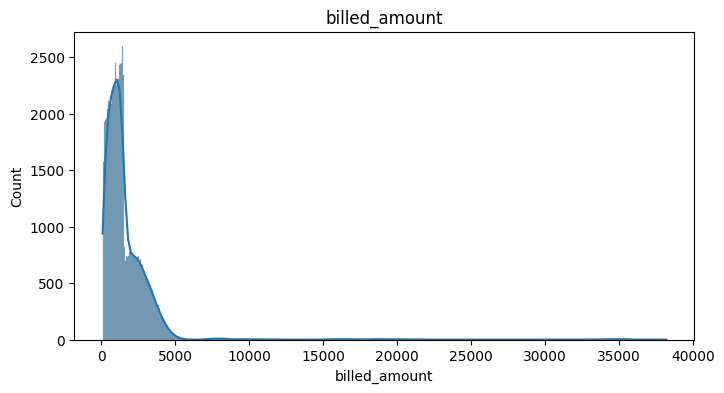

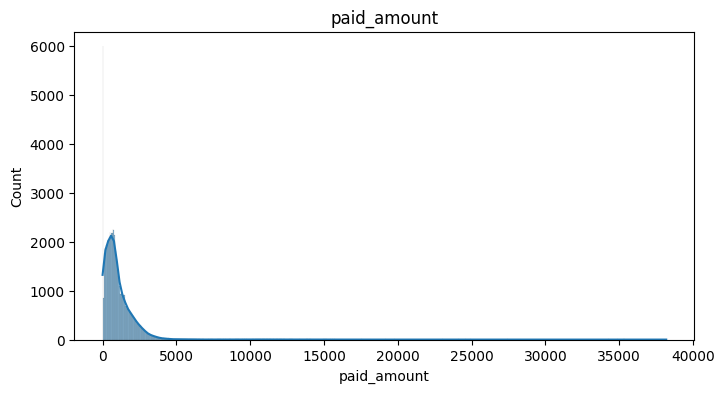

In [15]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))

    sns.histplot(
        billing[col],
        kde=True
    )

    plt.title(col)
    plt.show()

In [16]:
cat_cols = billing.select_dtypes(
    include='object'
).columns

cat_cols

Index(['billing_id', 'patient_id', 'encounter_id', 'insurance_provider',
       'payment_method', 'claim_id', 'claim_billing_date', 'claim_status',
       'denial_reason'],
      dtype='object')

In [17]:
for col in cat_cols:

    print("\n")
    print(col)

    print(
        billing[col]
        .value_counts()
        .head(10)
    )



billing_id
billing_id
BILL069984    1
BILL069983    1
BILL069982    1
BILL069981    1
BILL069980    1
BILL069979    1
BILL069978    1
BILL069977    1
BILL069976    1
BILL069975    1
Name: count, dtype: int64


patient_id
patient_id
PAT038089    5
PAT052502    5
PAT048145    5
PAT025642    4
PAT021503    4
PAT058697    4
PAT054767    4
PAT059588    4
PAT002977    4
PAT038017    4
Name: count, dtype: int64


encounter_id
encounter_id
ENC069984    1
ENC069983    1
ENC069982    1
ENC069981    1
ENC069980    1
ENC069979    1
ENC069978    1
ENC069977    1
ENC069976    1
ENC069975    1
Name: count, dtype: int64


insurance_provider
insurance_provider
Medicaid    10108
UHC         10062
BCBS        10004
Aetna       10004
Medicare     9983
Humana       9924
Cigna        9915
Name: count, dtype: int64


payment_method
payment_method
Insurance    59638
Selfpay      10362
Name: count, dtype: int64


claim_id
claim_id
CLM059638    1
CLM000001    1
CLM000002    1
CLM000003    1
CLM000004    1
CLM

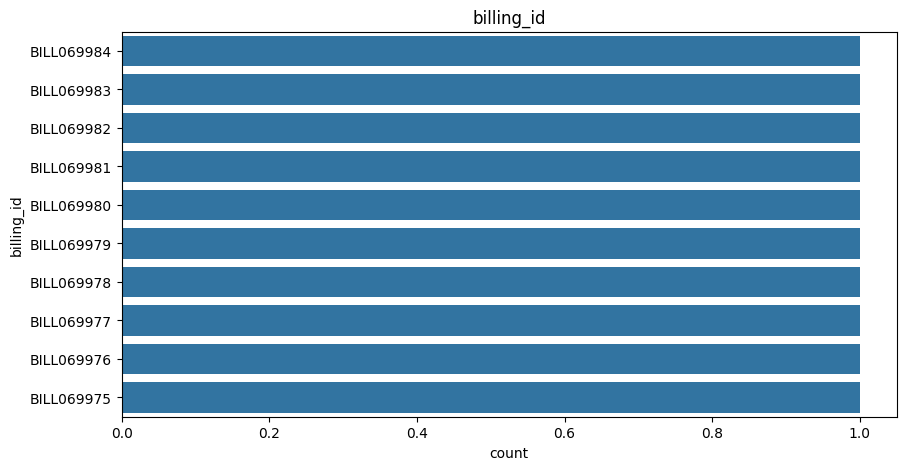

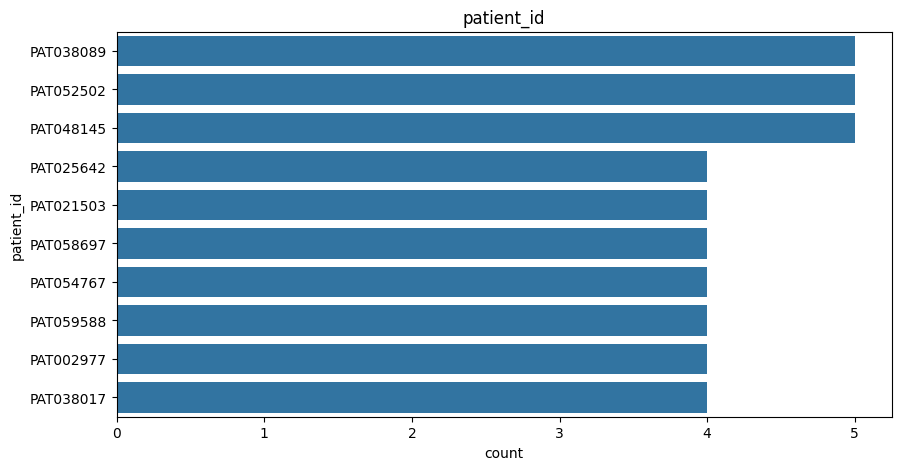

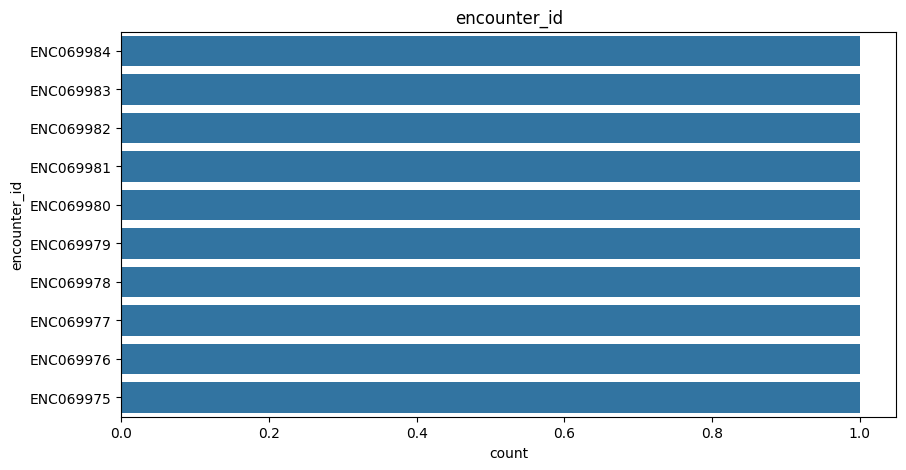

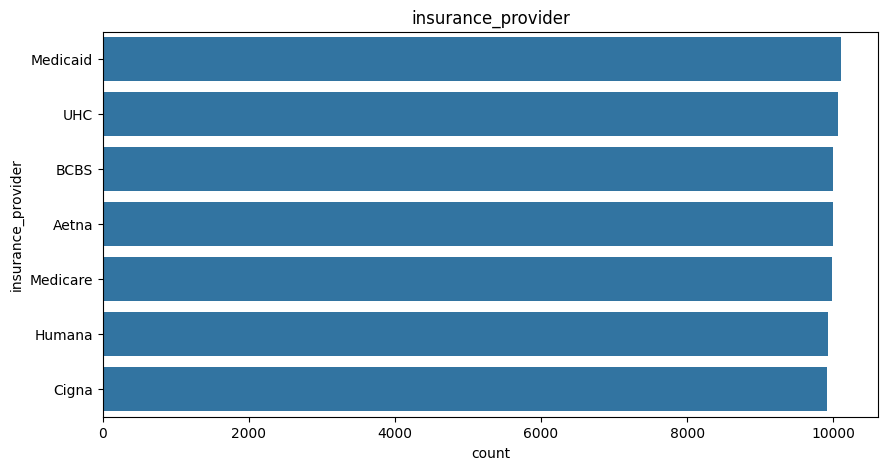

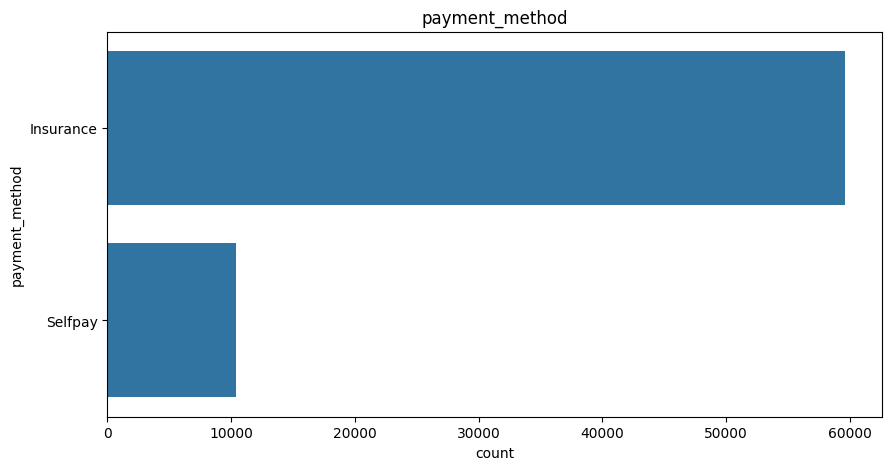

In [18]:
for col in cat_cols[:5]:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=billing[col],
        order=billing[col]
        .value_counts()
        .head(10)
        .index
    )

    plt.title(col)

    plt.show()

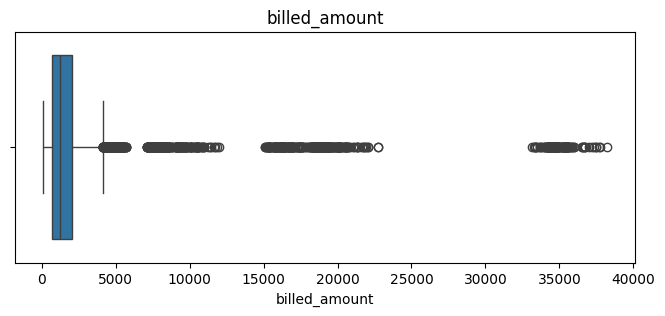

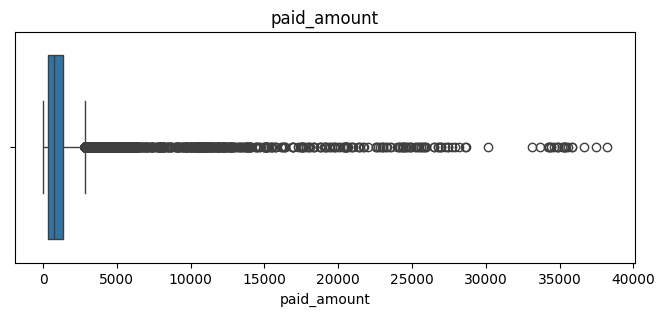

In [19]:
for col in num_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=billing[col]
    )

    plt.title(col)

    plt.show()

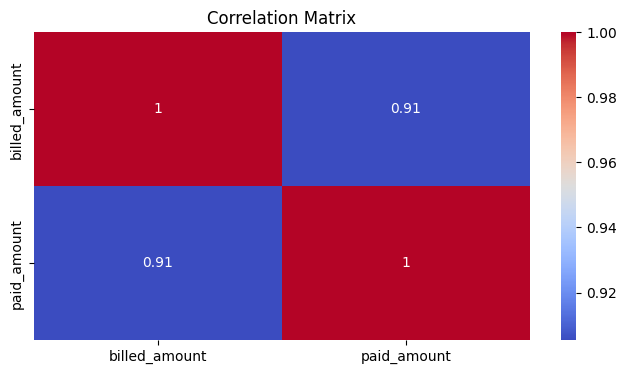

In [20]:
corr = billing[num_cols].corr()

plt.figure(figsize=(8,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [21]:
print("Total Revenue:", billing['paid_amount'].sum())

Total Revenue: 72845650.54


In [22]:
print("Total bill paid:", billing['billed_amount'].sum())

Total bill paid: 112900639.83999999


In [23]:
collection_Rate = (billing['paid_amount'].sum()/billing['billed_amount'].sum())*100
print("Collection Rate:", collection_Rate)

Collection Rate: 64.5219111629793


<Axes: xlabel='count', ylabel='insurance_provider'>

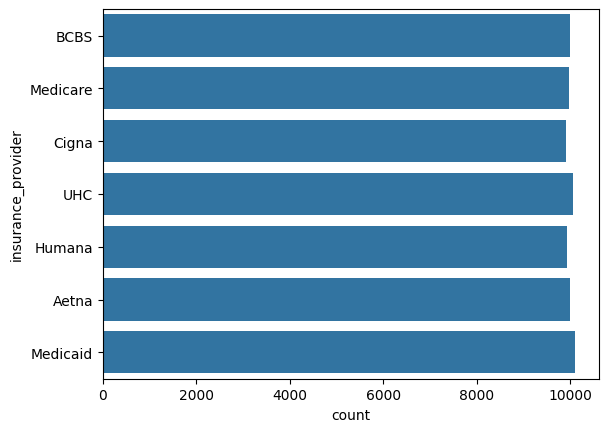

In [24]:
sns.countplot(
    y='insurance_provider',
    data=billing
)

<Axes: xlabel='count', ylabel='denial_reason'>

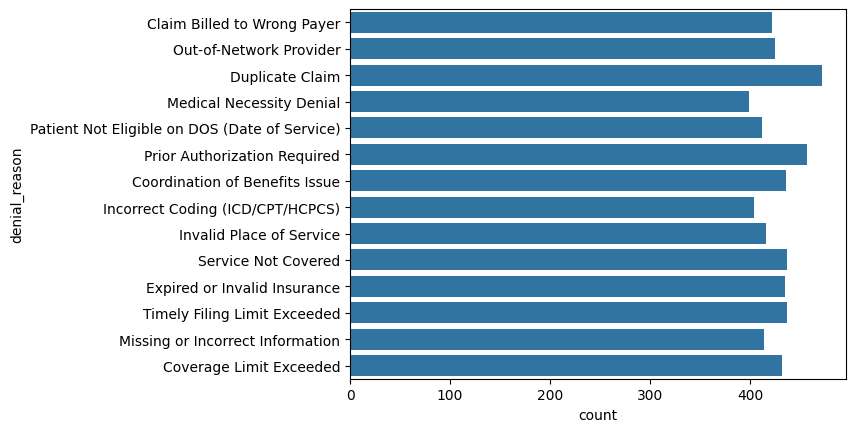

In [25]:
sns.countplot(
    y='denial_reason',
    data=billing
)

<Axes: xlabel='billed_amount', ylabel='paid_amount'>

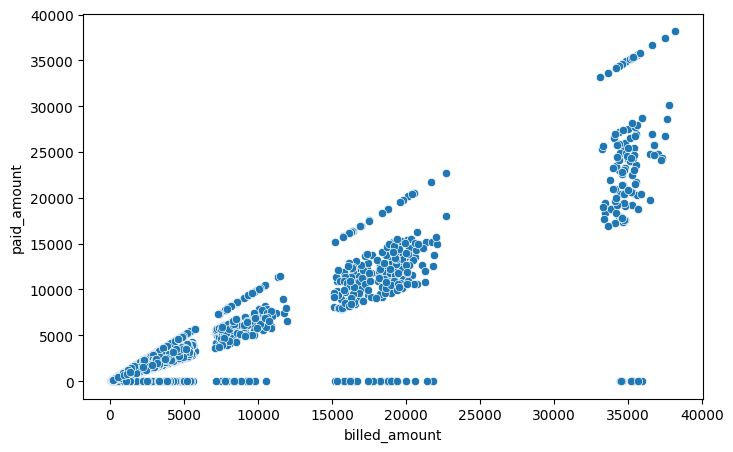

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='billed_amount',
    y='paid_amount',
    data=billing
)

### Analysis For denial dataset

In [27]:
denials = pd.read_csv('denials.csv')

In [28]:
denials.head()

,claim_id,denial_id,denial_reason_code,denial_reason_description,denied_amount,denial_date,appeal_filed,appeal_status,appeal_resolution_date,final_outcome
0,CLM000001,DEN00001,CO119,Claim billed to wrong payer.,1971.52,01-03-2025,Yes,Approved,10-03-2025,Paid
1,CLM000009,DEN00010,PR109,Claim not covered by this payer/contractor.,912.98,02-04-2025,No,NaN,NaN,NaN
2,CLM000021,DEN00024,CO18,Duplicate claim/service.,2078.53,30-03-2025,Yes,Approved,04-04-2025,Paid
3,CLM000032,DEN00035,CO50,These services are not medically necessary.,2242.83,29-04-2025,No,NaN,NaN,NaN
4,CLM000044,DEN00052,PR109,Claim not covered by this payer/contractor.,1157.46,16-05-2025,Yes,Approved,23-05-2025,Paid


In [29]:
denials.shape

(5998, 10)

In [30]:
denials.columns

Index(['claim_id', 'denial_id', 'denial_reason_code',
       'denial_reason_description', 'denied_amount', 'denial_date',
       'appeal_filed', 'appeal_status', 'appeal_resolution_date',
       'final_outcome'],
      dtype='object')

In [31]:
denials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   claim_id                   5998 non-null   object 
 1   denial_id                  5998 non-null   object 
 2   denial_reason_code         5998 non-null   object 
 3   denial_reason_description  5998 non-null   object 
 4   denied_amount              5998 non-null   float64
 5   denial_date                5998 non-null   object 
 6   appeal_filed               5998 non-null   object 
 7   appeal_status              5396 non-null   object 
 8   appeal_resolution_date     5396 non-null   object 
 9   final_outcome              5396 non-null   object 
dtypes: float64(1), object(9)
memory usage: 468.7+ KB


In [32]:
denials.describe()

,denied_amount
count,5998.00000
mean,1608.16611
std,1933.33737
min,101.58000
25%,697.38500
50%,1221.51000
75%,2102.14750
max,35956.07000


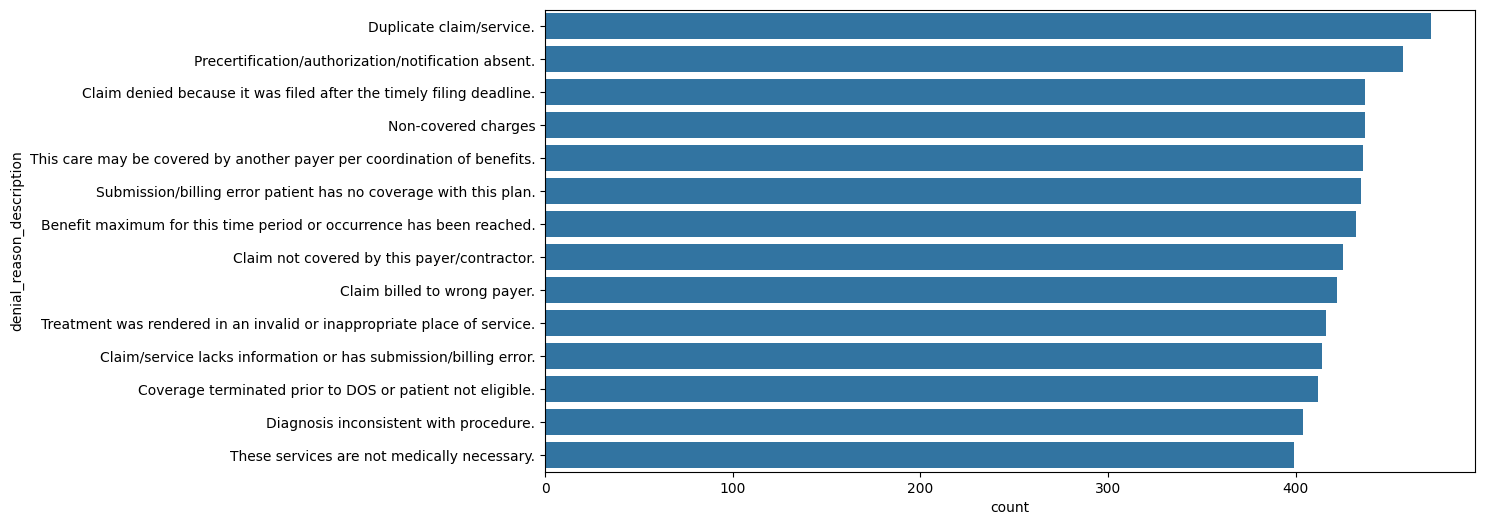

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='denial_reason_description',
    data=denials,
    order=denials['denial_reason_description']
          .value_counts()
          .index
)
plt.show()

In [34]:
print(denials['denied_amount'].sum())

9645780.33


In [35]:
print(denials['denied_amount'].mean())

1608.1661103701233


In [36]:
denials.nlargest(
    10,
    'denied_amount'
)

,claim_id,denial_id,denial_reason_code,denial_reason_description,denied_amount,denial_date,appeal_filed,appeal_status,appeal_resolution_date,final_outcome
4434,CLM044235,DEN51999,PR125,Submission/billing error patient has no covera...,35956.07,04-03-2025,Yes,Approved,09-03-2025,Paid
5594,CLM055533,DEN65172,CO50,These services are not medically necessary.,35666.30,05-03-2025,Yes,Approved,12-03-2025,Paid
1370,CLM013295,DEN15560,CO119,Claim billed to wrong payer.,35334.00,16-03-2025,Yes,Denied,26-03-2025,Written off
5436,CLM054052,DEN63445,PR125,Submission/billing error patient has no covera...,35196.79,09-05-2025,Yes,Approved,18-05-2025,Paid
3010,CLM029825,DEN34999,CO197,Precertification/authorization/notification ab...,34597.39,17-02-2025,Yes,Approved,26-02-2025,Paid
5763,CLM057195,DEN67132,CO16,Claim/service lacks information or has submiss...,34546.47,23-03-2025,Yes,Approved,28-03-2025,Paid
5363,CLM053385,DEN62678,CO50,These services are not medically necessary.,34458.24,08-03-2025,Yes,Approved,15-03-2025,Paid
548,CLM005521,DEN06420,CO16,Claim/service lacks information or has submiss...,21832.93,16-05-2025,Yes,Pending,21-05-2025,Reprocessed
3687,CLM036805,DEN43206,PR125,Submission/billing error patient has no covera...,21456.15,09-04-2025,Yes,Approved,16-04-2025,Paid
2622,CLM025798,DEN30292,CO58,Treatment was rendered in an invalid or inappr...,20618.99,23-04-2025,Yes,Pending,30-04-2025,Reprocessed


In [37]:
denials['appeal_filed'].value_counts(normalize=True)*100

appeal_filed
Yes    89.963321
No     10.036679
Name: proportion, dtype: float64

In [38]:
denials['appeal_status'].value_counts()

appeal_status
Approved    4319
Denied       544
Pending      533
Name: count, dtype: int64

In [39]:
denials['final_outcome'].value_counts()

final_outcome
Paid           4319
Written off     544
Reprocessed     533
Name: count, dtype: int64

In [40]:
reason_amount = (
    denials.groupby(
        'denial_reason_description'
    )['denied_amount']
    .sum()
    .sort_values(ascending=False)
)

In [41]:
pd.crosstab(
    denials['denial_reason_description'],
    denials['final_outcome']
)

final_outcome,Paid,Reprocessed,Written off
denial_reason_description,,,
Benefit maximum for this time period or occurrence has been reached.,300,33,38
Claim billed to wrong payer.,299,38,35
Claim denied because it was filed after the timely filing deadline.,303,46,46
Claim not covered by this payer/contractor.,314,43,32
Claim/service lacks information or has submission/billing error.,300,31,41
Coverage terminated prior to DOS or patient not eligible.,296,31,41
Diagnosis inconsistent with procedure.,280,42,40
Duplicate claim/service.,350,39,41
Non-covered charges,312,43,40


In [44]:
patients = pd.read_csv('patients.csv')

In [45]:
patients.head()

,patient_id,first_name,last_name,dob,age,gender,ethnicity,insurance_type,marital_status,address,city,state,zip,phone,email,registration_date
0,PAT000001,Danielle,Johnson,14-05-1940,85,Female,Asian,UHC,Married,32181 Johnson Course Apt. 389,Bakersfield,CA,93301.0,NaN,danielle.johnson40@example.com,03-01-2025
1,PAT000002,Anna,Baldwin,04-03-2010,15,Female,White,Aetna,Married,79402 Peterson Drives Apt. 511,Bakersfield,CA,93301.0,(615)759 407,anna.baldwin294@example.com,26-02-2025
2,PAT000003,James,Jones,31-03-2021,4,Male,White,UHC,Married,1316 Chavez Village,Portland,OR,97035.0,(925)853 419,james.jones377@example.com,27-01-2025
3,PAT000004,Veronica,Bowman,26-08-1976,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,503 Linda Locks,Seattle,WA,98101.0,NaN,veronica.bowman653@example.com,26-01-2025
4,PAT000005,Carl,Gentry,06-01-1942,83,Male,Hispanic,BCBS,Married,NaN,NaN,NaN,NaN,001 553 676,carl.gentry91@example.com,14-03-2025


In [46]:
patients.shape

(60000, 16)

In [47]:
patients.columns

Index(['patient_id', 'first_name', 'last_name', 'dob', 'age', 'gender',
       'ethnicity', 'insurance_type', 'marital_status', 'address', 'city',
       'state', 'zip', 'phone', 'email', 'registration_date'],
      dtype='object')

In [48]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         60000 non-null  object 
 1   first_name         60000 non-null  object 
 2   last_name          60000 non-null  object 
 3   dob                60000 non-null  object 
 4   age                60000 non-null  int64  
 5   gender             60000 non-null  object 
 6   ethnicity          60000 non-null  object 
 7   insurance_type     60000 non-null  object 
 8   marital_status     60000 non-null  object 
 9   address            54063 non-null  object 
 10  city               54063 non-null  object 
 11  state              54063 non-null  object 
 12  zip                54063 non-null  float64
 13  phone              53996 non-null  object 
 14  email              47962 non-null  object 
 15  registration_date  60000 non-null  object 
dtypes: float64(1), int64(1

In [49]:
patients.describe()

,age,zip
count,60000.000000,54063.000000
mean,46.987800,92196.901689
std,25.138112,4431.118184
min,4.000000,75001.000000
25%,25.000000,90802.000000
50%,47.000000,93301.000000
75%,69.000000,94203.000000
max,90.000000,98101.000000


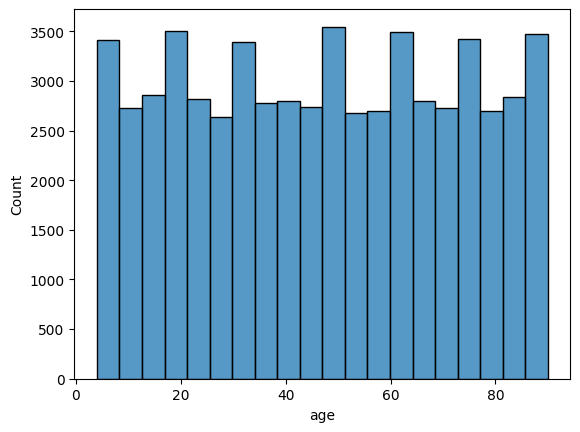

In [50]:
sns.histplot(patients['age'], bins=20)
plt.show()

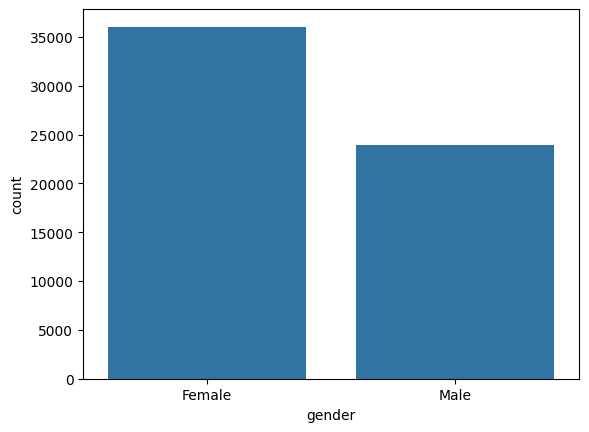

In [51]:
sns.countplot(x='gender', data=patients)
plt.show()